In [1]:
import pandas as pd

json_file="ecommerce_logs.json"
# Read JSON
df = pd.read_json(json_file)

# Save as CSV
df.to_csv("ecommerce_logs.csv", index=False)

print("✅ Converted successfully!")


✅ Converted successfully!


In [2]:
df.head()

,log_id,timestamp,user_id,session_id,service,event_type,product_id,category,price,quantity,payment_method,payment_status,response_time_ms,status_code,region,location,device,ip_address,is_fraud,cart_abandonment_spike
0,b91763f4-4f4c-4823-8b05-08c0f84775f5,2024-08-02 08:28:15,user_2529,752a1474-2e12-4ea9-be35-71e501445029,cart_service,checkout,prod_316,electronics,152.58,2,wallet,None,3781,200,IN,Hyderabad,tablet,116.133.91.207,0,0
1,0ccb1c22-2154-4ebf-b6f7-3e06311e0837,2024-12-10 09:40:26,user_854,8377c400-bb43-445d-bb87-64b36f907192,payment_service,payment_failed,prod_246,electronics,1761.98,2,upi,failed,240,200,APAC,Bangalore,desktop,251.135.9.219,0,0
2,226e6d64-48b4-49bf-b326-cf63b894305f,2024-11-09 02:28:34,user_4931,99ffea0e-2a14-4bd4-b6cf-0cf9b8c7decc,cart_service,remove_from_cart,prod_222,sports,1939.18,5,wallet,None,447,200,EU,Bangalore,desktop,178.83.159.212,0,0
3,03e35359-c0a7-490c-a56b-e7ae21b8fff4,2024-05-01 09:48:54,user_4749,3f34028b-f6d9-44d1-a5f0-385021746a89,payment_service,payment_success,prod_117,sports,923.73,3,upi,success,2122,200,US,Hyderabad,mobile,142.250.151.87,0,0
4,8ecc4cbd-f0a1-4db5-b63b-25e56d8776ff,2024-12-26 01:21:36,user_4226,d22fb93d-4d10-44a1-b367-0c81c695f495,order_service,add_to_cart,prod_113,home,1496.18,2,netbanking,None,4655,500,APAC,Delhi,tablet,195.124.125.39,0,0


In [3]:
df.isnull().sum()


log_id                        0
timestamp                     0
user_id                       0
session_id                    0
service                       0
event_type                    0
product_id                    0
category                      0
price                         0
quantity                      0
payment_method                0
payment_status            33242
response_time_ms              0
status_code                   0
region                        0
location                      0
device                        0
ip_address                    0
is_fraud                      0
cart_abandonment_spike        0
dtype: int64

In [5]:
# Step 1: Not applicable for non-purchase
df["payment_status"] = df.apply(
    lambda x: "not_applicable" if x["event_type"] != "purchase" else x["payment_status"],
    axis=1
)

# Step 2: Fill remaining missing
df["payment_status"] = df["payment_status"].fillna("unknown")



In [6]:
df.head()

,log_id,timestamp,user_id,session_id,service,event_type,product_id,category,price,quantity,payment_method,payment_status,response_time_ms,status_code,region,location,device,ip_address,is_fraud,cart_abandonment_spike
0,b91763f4-4f4c-4823-8b05-08c0f84775f5,2024-08-02 08:28:15,user_2529,752a1474-2e12-4ea9-be35-71e501445029,cart_service,checkout,prod_316,electronics,152.58,2,wallet,not_applicable,3781,200,IN,Hyderabad,tablet,116.133.91.207,0,0
1,0ccb1c22-2154-4ebf-b6f7-3e06311e0837,2024-12-10 09:40:26,user_854,8377c400-bb43-445d-bb87-64b36f907192,payment_service,payment_failed,prod_246,electronics,1761.98,2,upi,not_applicable,240,200,APAC,Bangalore,desktop,251.135.9.219,0,0
2,226e6d64-48b4-49bf-b326-cf63b894305f,2024-11-09 02:28:34,user_4931,99ffea0e-2a14-4bd4-b6cf-0cf9b8c7decc,cart_service,remove_from_cart,prod_222,sports,1939.18,5,wallet,not_applicable,447,200,EU,Bangalore,desktop,178.83.159.212,0,0
3,03e35359-c0a7-490c-a56b-e7ae21b8fff4,2024-05-01 09:48:54,user_4749,3f34028b-f6d9-44d1-a5f0-385021746a89,payment_service,payment_success,prod_117,sports,923.73,3,upi,not_applicable,2122,200,US,Hyderabad,mobile,142.250.151.87,0,0
4,8ecc4cbd-f0a1-4db5-b63b-25e56d8776ff,2024-12-26 01:21:36,user_4226,d22fb93d-4d10-44a1-b367-0c81c695f495,order_service,add_to_cart,prod_113,home,1496.18,2,netbanking,not_applicable,4655,500,APAC,Delhi,tablet,195.124.125.39,0,0


In [7]:
df.duplicated().sum()


np.int64(0)

In [15]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["month"] = df["timestamp"].dt.month


In [16]:
df.head(20)

,log_id,timestamp,user_id,session_id,service,event_type,product_id,category,price,quantity,...,status_code,region,location,device,ip_address,is_fraud,cart_abandonment_spike,hour,day,month
0,b91763f4-4f4c-4823-8b05-08c0f84775f5,2024-08-02 08:28:15,user_2529,752a1474-2e12-4ea9-be35-71e501445029,cart_service,checkout,prod_316,electronics,152.58,2,...,200,IN,Hyderabad,tablet,116.133.91.207,0,0,8,4,8
1,0ccb1c22-2154-4ebf-b6f7-3e06311e0837,2024-12-10 09:40:26,user_854,8377c400-bb43-445d-bb87-64b36f907192,payment_service,payment_failed,prod_246,electronics,1761.98,2,...,200,APAC,Bangalore,desktop,251.135.9.219,0,0,9,1,12
3,03e35359-c0a7-490c-a56b-e7ae21b8fff4,2024-05-01 09:48:54,user_4749,3f34028b-f6d9-44d1-a5f0-385021746a89,payment_service,payment_success,prod_117,sports,923.73,3,...,200,US,Hyderabad,mobile,142.250.151.87,0,0,9,2,5
4,8ecc4cbd-f0a1-4db5-b63b-25e56d8776ff,2024-12-26 01:21:36,user_4226,d22fb93d-4d10-44a1-b367-0c81c695f495,order_service,add_to_cart,prod_113,home,1496.18,2,...,500,APAC,Delhi,tablet,195.124.125.39,0,0,1,3,12
5,a9571e58-94d6-482a-b43d-048aa712d98e,2024-11-08 06:40:28,user_2520,6c802e74-8974-4d67-adb9-0e25d5e1a2ce,payment_service,checkout,prod_752,electronics,1629.31,3,...,200,IN,Hyderabad,desktop,130.127.45.186,0,0,6,4,11
6,636f2afc-a91c-4bba-ad64-7f73ad0fd711,2024-10-25 10:00:12,user_4440,c9869a86-db6d-43b5-83cb-e980519aa19d,payment_service,checkout,prod_969,electronics,1031.98,3,...,500,APAC,Delhi,desktop,122.18.60.52,0,0,10,4,10
7,76cdb873-d559-4214-970c-431075f88199,2024-11-30 00:14:55,user_4903,2526bff2-0268-471c-96ba-061bab16ba5e,user_service,add_to_cart,prod_15,fashion,1599.65,2,...,200,IN,Kolkata,tablet,219.184.149.165,0,0,0,5,11
8,aaabd2e8-8a99-4e5d-b653-259abf990f03,2024-11-25 20:21:08,user_335,0b805613-0ed6-4f1f-a416-62f2d036578f,order_service,checkout,prod_697,home,738.26,1,...,500,EU,Chennai,desktop,123.182.196.4,0,0,20,0,11
9,0a451715-2fe0-4f0c-b89c-6d6a96af7b5f,2024-05-08 16:47:29,user_656,0b4359e2-a60a-4fcd-b184-5fc05d67a8d0,order_service,checkout,prod_726,sports,1562.97,4,...,200,EU,Delhi,desktop,206.143.103.235,0,0,16,2,5
10,66490272-5a24-421a-8368-4506635f0357,2024-05-25 11:16:51,user_4216,bddda846-4c98-4e3b-b85f-4990cf3ce7bf,payment_service,payment_failed,prod_911,home,591.90,2,...,200,APAC,Pune,desktop,157.4.228.217,0,1,11,5,5


In [11]:
# Remove extreme values
df = df[df["price"] < df["price"].quantile(0.99)]
df = df[df["quantity"] < df["quantity"].quantile(0.99)]


In [12]:
df.head()

,log_id,timestamp,user_id,session_id,service,event_type,product_id,category,price,quantity,...,status_code,region,location,device,ip_address,is_fraud,cart_abandonment_spike,hour,day,month
0,b91763f4-4f4c-4823-8b05-08c0f84775f5,2024-08-02 08:28:15,user_2529,752a1474-2e12-4ea9-be35-71e501445029,cart_service,checkout,prod_316,electronics,152.58,2,...,200,IN,Hyderabad,tablet,116.133.91.207,0,0,8,4,8
1,0ccb1c22-2154-4ebf-b6f7-3e06311e0837,2024-12-10 09:40:26,user_854,8377c400-bb43-445d-bb87-64b36f907192,payment_service,payment_failed,prod_246,electronics,1761.98,2,...,200,APAC,Bangalore,desktop,251.135.9.219,0,0,9,1,12
3,03e35359-c0a7-490c-a56b-e7ae21b8fff4,2024-05-01 09:48:54,user_4749,3f34028b-f6d9-44d1-a5f0-385021746a89,payment_service,payment_success,prod_117,sports,923.73,3,...,200,US,Hyderabad,mobile,142.250.151.87,0,0,9,2,5
4,8ecc4cbd-f0a1-4db5-b63b-25e56d8776ff,2024-12-26 01:21:36,user_4226,d22fb93d-4d10-44a1-b367-0c81c695f495,order_service,add_to_cart,prod_113,home,1496.18,2,...,500,APAC,Delhi,tablet,195.124.125.39,0,0,1,3,12
5,a9571e58-94d6-482a-b43d-048aa712d98e,2024-11-08 06:40:28,user_2520,6c802e74-8974-4d67-adb9-0e25d5e1a2ce,payment_service,checkout,prod_752,electronics,1629.31,3,...,200,IN,Hyderabad,desktop,130.127.45.186,0,0,6,4,11


In [17]:
df.columns

Index(['log_id', 'timestamp', 'user_id', 'session_id', 'service', 'event_type',
       'product_id', 'category', 'price', 'quantity', 'payment_method',
       'payment_status', 'response_time_ms', 'status_code', 'region',
       'location', 'device', 'ip_address', 'is_fraud',
       'cart_abandonment_spike', 'hour', 'day', 'month'],
      dtype='object')

In [18]:
df["cart_dropoff"] = (
    (df["event_type"] == "add_to_cart") &
    (df["payment_status"] != "success")
).astype(int)


In [19]:
df["location_switch"] = df.groupby("user_id")["location"].transform("nunique")


In [20]:
df["region_change"] = (df["location_switch"] > 2).astype(int)


In [22]:
df.head()

,log_id,timestamp,user_id,session_id,service,event_type,product_id,category,price,quantity,...,device,ip_address,is_fraud,cart_abandonment_spike,hour,day,month,cart_dropoff,location_switch,region_change
0,b91763f4-4f4c-4823-8b05-08c0f84775f5,2024-08-02 08:28:15,user_2529,752a1474-2e12-4ea9-be35-71e501445029,cart_service,checkout,prod_316,electronics,152.58,2,...,tablet,116.133.91.207,0,0,8,4,8,0,6,1
1,0ccb1c22-2154-4ebf-b6f7-3e06311e0837,2024-12-10 09:40:26,user_854,8377c400-bb43-445d-bb87-64b36f907192,payment_service,payment_failed,prod_246,electronics,1761.98,2,...,desktop,251.135.9.219,0,0,9,1,12,0,4,1
3,03e35359-c0a7-490c-a56b-e7ae21b8fff4,2024-05-01 09:48:54,user_4749,3f34028b-f6d9-44d1-a5f0-385021746a89,payment_service,payment_success,prod_117,sports,923.73,3,...,mobile,142.250.151.87,0,0,9,2,5,0,6,1
4,8ecc4cbd-f0a1-4db5-b63b-25e56d8776ff,2024-12-26 01:21:36,user_4226,d22fb93d-4d10-44a1-b367-0c81c695f495,order_service,add_to_cart,prod_113,home,1496.18,2,...,tablet,195.124.125.39,0,0,1,3,12,1,6,1
5,a9571e58-94d6-482a-b43d-048aa712d98e,2024-11-08 06:40:28,user_2520,6c802e74-8974-4d67-adb9-0e25d5e1a2ce,payment_service,checkout,prod_752,electronics,1629.31,3,...,desktop,130.127.45.186,0,0,6,4,11,0,5,1


In [23]:
df.columns

Index(['log_id', 'timestamp', 'user_id', 'session_id', 'service', 'event_type',
       'product_id', 'category', 'price', 'quantity', 'payment_method',
       'payment_status', 'response_time_ms', 'status_code', 'region',
       'location', 'device', 'ip_address', 'is_fraud',
       'cart_abandonment_spike', 'hour', 'day', 'month', 'cart_dropoff',
       'location_switch', 'region_change'],
      dtype='object')

In [24]:
df["is_fraud"].value_counts()


is_fraud
0    38753
1      780
Name: count, dtype: int64

In [25]:
df["is_fraud"].value_counts(normalize=True) * 100


is_fraud
0    98.026965
1     1.973035
Name: proportion, dtype: float64

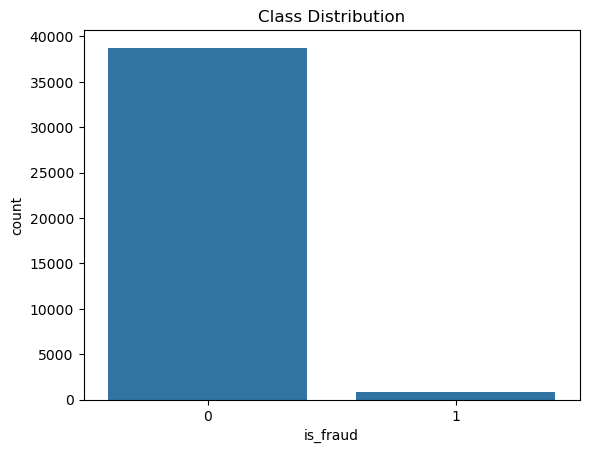

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="is_fraud", data=df)
plt.title("Class Distribution")
plt.show()


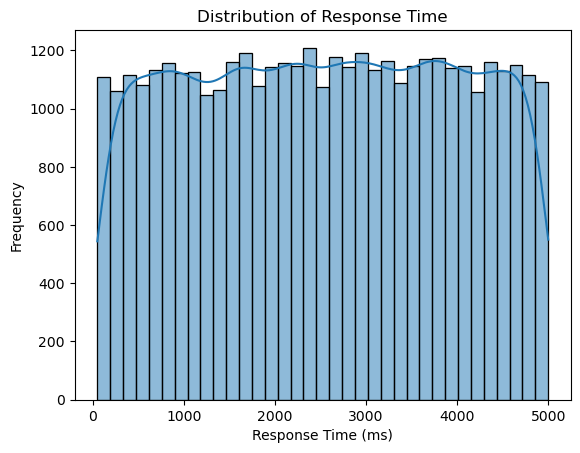

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["response_time_ms"], kde=True)
plt.title("Distribution of Response Time")
plt.xlabel("Response Time (ms)")
plt.ylabel("Frequency")
plt.show()


In [29]:
from sklearn.utils import resample

df_major = df[df.is_fraud == 0]
df_minor = df[df.is_fraud == 1]

df_major_down = resample(df_major,
                        replace=False,
                        n_samples=len(df_minor),
                        random_state=42)

df_balanced = pd.concat([df_major_down, df_minor])


In [37]:
from sklearn.ensemble import IsolationForest

cols = ["price", "quantity", "response_time_ms"]

iso = IsolationForest(contamination=0.02, random_state=42)

df["outlier_flag"] = iso.fit_predict(df[cols])

# -1 = outlier, 1 = normal
df["outlier_flag"] = df["outlier_flag"].map({1: 0, -1: 1})


In [38]:
df["outlier_flag"].value_counts()


outlier_flag
0    38742
1      791
Name: count, dtype: int64

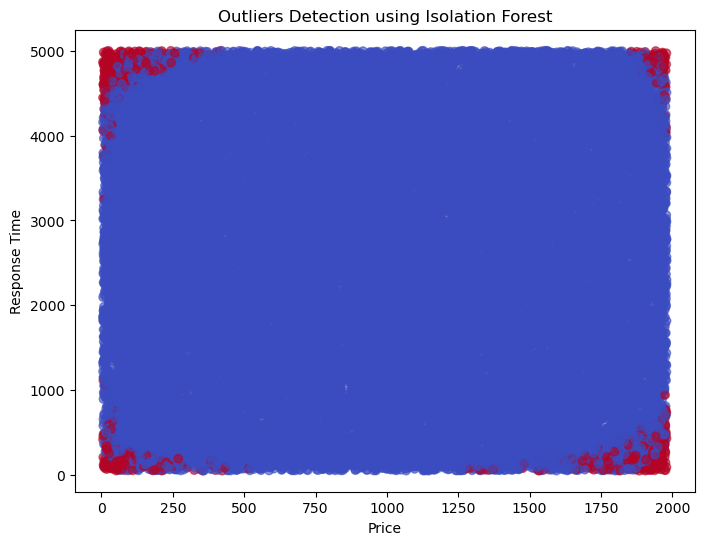

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["price"], df["response_time_ms"],
            c=df["outlier_flag"], cmap="coolwarm", alpha=0.6)

plt.xlabel("Price")
plt.ylabel("Response Time")
plt.title("Outliers Detection using Isolation Forest")

plt.show()


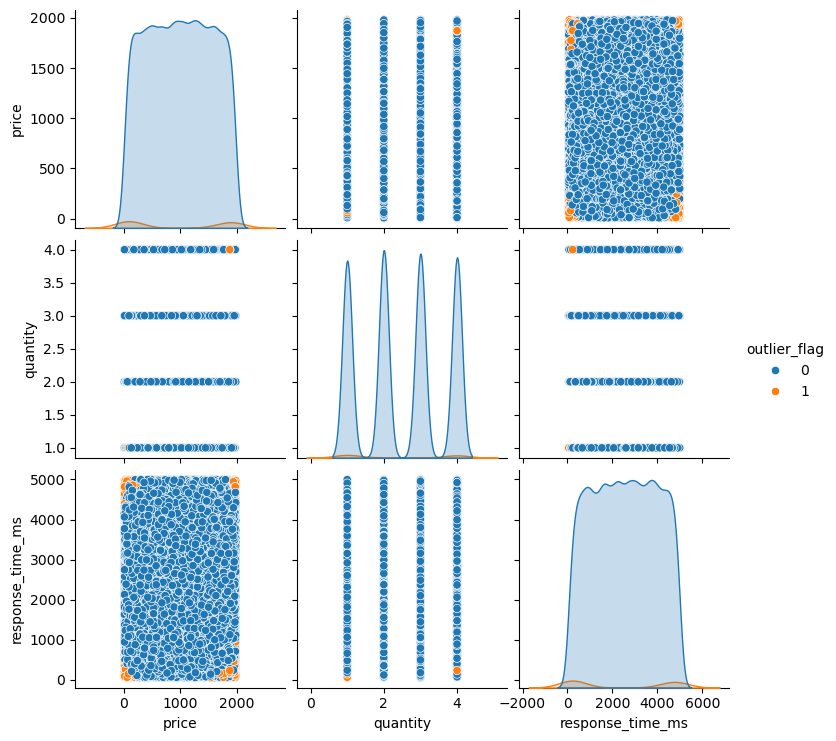

In [42]:
sns.pairplot(df[["price","quantity","response_time_ms","outlier_flag"]],
             hue="outlier_flag")
plt.show()


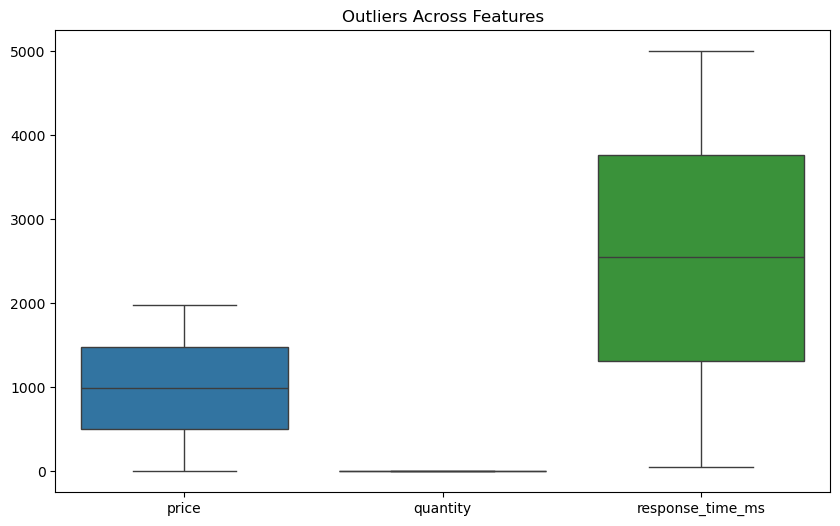

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["price", "quantity", "response_time_ms"]

plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols], orient="v")
plt.title("Outliers Across Features")
plt.show()

In [45]:
print(df["quantity"].describe())


count    39533.000000
mean         2.501303
std          1.116791
min          1.000000
25%          2.000000
50%          2.000000
75%          4.000000
max          4.000000
Name: quantity, dtype: float64
